变分量子特征求解器（VQE）算法
=======================

变分量子特征求解器（Variational Quantum Eigensolver, VQE）是一种利用量子计算机进行量子化学计算的算法 [1]。它是Ritz变分原理在量子计算领域的应用，其基本思想是训练量子计算机制备给定分子的基态。

Ritz变分原理指出，任意试探波函数的期望值都不小于体系的基态能量。VQE算法正是利用了这一原理，通过优化试探波函数的参数，使其尽可能逼近分子体系的基态。

具体而言，VQE算法首先在量子计算机上构建一组参数化的量子门电路，用于制备试探波函数。接着，通过测量哈密顿量在该试探态下的期望值，并利用经典优化算法调整电路参数，最终得到哈密顿量的最低特征值，以及相应的基态波函数。这一过程可以看作是在变分空间中寻找最优的量子态，因此得名"变分量子特征求解器"。

VQE算法的一大优势在于，它对量子比特的相干时间要求较低，因此非常适用于目前的中小规模量子计算机。此外，通过采用合适的试探波函数，VQE算法还可以很好地利用经典计算资源，从而进一步降低对量子计算能力的要求。

总的来说，VQE算法为研究人员提供了一种在近期量子设备上模拟复杂量子体系的新思路，有望在量子化学、材料科学等领域取得重要应用。

本教程将展示如何用几行代码实现VQE算法。作为示例，我们用它来求解氢分子H2的基态。首先，我们使用最小基组近似构建分子哈密顿量。然后设计用于制备分子试探态的量子线路，以及评估哈密顿量期望值的损失函数。最后，我们选择一个经典优化器，初始化电线参数,并用基于DeepQuantum的量子线路运行VQE算法。

让我们开始吧!

构建电子哈密顿量
----------

我们先构建氢分子的电子哈密顿量（泡利算符线性组合形式）以及量子模拟所需的量子比特数。在这个例子中，我们使用最小基组来表示分子轨道。在这个近似下，我们有4个自旋轨道，它定义了量子比特数。此外，我们使用Jordan-Wigner变换执行哈密顿量的费米子到量子比特的映射 [2]。以下是氢分子的电子哈密顿量：

H=
   (-0.042072551947440084) [I0]
  \+ (-0.24274501260941383) [Z3]
  \+ (-0.24274501260941383) [Z2]
  \+ (0.1777135822909176) [Z0]
  \+ (0.1777135822909176) [Z1]
  \+ (0.12293330449299354) [Z0 Z2]
  \+ (0.12293330449299354) [Z1 Z3]
  \+ (0.1676833885560135) [Z0 Z3]
  \+ (0.1676833885560135) [Z1 Z2]
  \+ (0.17059759276836806) [Z0 Z1]
  \+ (0.17627661394181787) [Z2 Z3]
  \+ (-0.04475008406301996) [Y0 Y1 X2 X3]
  \+ (-0.04475008406301996) [X0 X1 Y2 Y3]
  \+ (0.04475008406301996) [Y0 X1 X2 Y3]
  \+ (0.04475008406301996) [X0 Y1 Y2 X3]


实现VQE算法
-------------

我们需要定义用于制备分子试探态的量子线路。我们希望制备如下形式的态:
 
$$\vert \Psi(\theta) \rangle = \cos(\theta/2)~|1100\rangle -\sin(\theta/2)~|0011\rangle$$ 

其中 $\theta$ 是变分参数，需要优化以找到真实基态的最佳近似。在Jordan-Wigner编码中，第一项 $|1100\rangle$ 表示两个电子占据最低能量轨道的Hartree-Fock (HF)态。第二项 $|0011\rangle$ 编码了HF态的双重激发，其中两个粒子从量子比特0，1激发到2，3。

制备试探态 $\vert \Psi(\theta) \rangle$ 的量子线路如下图所示。

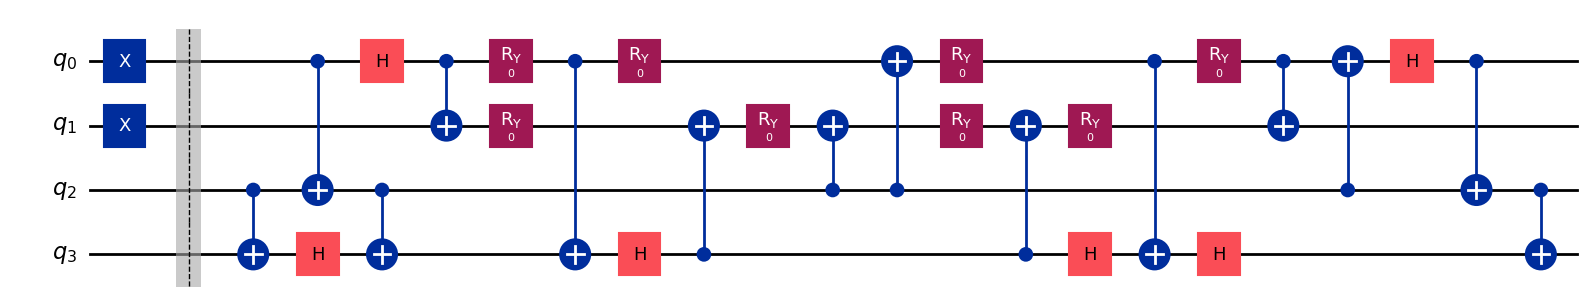

In [1]:
import deepquantum as dq
import torch
import torch.nn as nn

phi=0
n_qubits = 4  #定义比特个数
cir = dq.QubitCircuit(n_qubits)

def circuit(phi):
    cir.x(0)
    cir.x(1)

    cir.barrier()

    cir.cnot(2,3)
    cir.cnot(0,2)
    cir.h(3)
    cir.h(0)
    cir.cnot(2,3)
    cir.cnot(0,1)
    cir.ry(1,phi / 8)
    cir.ry(0,-phi / 8)
    cir.cnot(0,3)
    cir.h(3)
    cir.cnot(3,1)
    cir.ry(1,phi / 8)
    cir.ry(0,-phi / 8)
    cir.cnot(2,1)
    cir.cnot(2,0)
    cir.ry(1,-phi / 8)
    cir.ry(0,phi / 8)
    cir.cnot(3,1)
    cir.h(3)
    cir.cnot(0,3)
    cir.ry(1,-phi / 8)
    cir.ry(0,phi / 8)
    cir.cnot(0,1)
    cir.cnot(2,0)
    cir.h(0)
    cir.h(3)
    cir.cnot(0,2)
    cir.cnot(2,3)

    return cir

cir=circuit(phi)
cir.draw()

下一步是计算电路制备的试探态下分子哈密顿量的期望值。

In [2]:
def circuit_measure(cir):

    cir.observable(wires=[2], basis='z')
    cir.observable(wires=[3], basis='z')
    cir.observable(wires=[0], basis='z')
    cir.observable(wires=[1], basis='z')
    
    cir.observable(wires=[0,2], basis='zz')
    cir.observable(wires=[1,3], basis='zz')
    cir.observable(wires=[0,3], basis='zz')
    cir.observable(wires=[1,2], basis='zz')
    cir.observable(wires=[0,1], basis='zz')
    cir.observable(wires=[2,3], basis='zz')

    cir.observable(wires=[0,1,2,3], basis='yyxx')
    cir.observable(wires=[0,1,2,3], basis='xxyy')
    cir.observable(wires=[0,1,2,3], basis='yxxy')
    cir.observable(wires=[0,1,2,3], basis='xyyx')

    cir()
    return cir.expectation() 

res=circuit_measure(cir)
energy=(-0.042072551947440084)+(-0.24274501260941383)*res[0]+(-0.24274501260941383)*res[1]+(0.1777135822909176)*res[2]+(0.1777135822909176)*res[3]+(0.12293330449299354)*res[4]+(0.12293330449299354)*res[5]+(0.1676833885560135)*res[6]+\
(0.1676833885560135)*res[7]+(0.17059759276836806)*res[8]+(0.17627661394181787)*res[9]+(-0.04475008406301996)*res[10]+(-0.04475008406301996)*res[11]+(0.04475008406301996)*res[12]+(0.04475008406301996)*res[13]

print(energy)

tensor(-1.1173)


接下来我们整理一下上述信息，通过最小化损失函数来求解 $\mathrm{H}_2$ 分子的基态。

In [3]:
class Model(nn.Module):
    def __init__(self, n_qubits):
        super(Model, self).__init__()

        self.phi = nn.Parameter(torch.tensor(0.0)) # 定义可迭代变量phi

    def forward(self):

        phi=self.phi
        self.cir = dq.QubitCircuit(4) #定义比特个数
        self.cir.x(0)
        self.cir.x(1)
        self.cir.barrier()
        self.cir.cnot(2,3)
        self.cir.cnot(0,2)
        self.cir.h(3)
        self.cir.h(0)
        self.cir.cnot(2,3)
        self.cir.cnot(0,1)
        self.cir.ry(1,phi / 8)
        self.cir.ry(0,-phi / 8)
        self.cir.cnot(0,3)
        self.cir.h(3)
        self.cir.cnot(3,1)
        self.cir.ry(1,phi / 8)
        self.cir.ry(0,-phi / 8)
        self.cir.cnot(2,1)
        self.cir.cnot(2,0)
        self.cir.ry(1,-phi / 8)
        self.cir.ry(0,phi / 8)
        self.cir.cnot(3,1)
        self.cir.h(3)
        self.cir.cnot(0,3)
        self.cir.ry(1,-phi / 8)
        self.cir.ry(0,phi / 8)
        self.cir.cnot(0,1)
        self.cir.cnot(2,0)
        self.cir.h(0)
        self.cir.h(3)
        self.cir.cnot(0,2)
        self.cir.cnot(2,3)

        self.cir.observable(wires=[2], basis='z')
        self.cir.observable(wires=[3], basis='z')
        self.cir.observable(wires=[0], basis='z')
        self.cir.observable(wires=[1], basis='z')
        self.cir.observable(wires=[0,2], basis='zz')
        self.cir.observable(wires=[1,3], basis='zz')
        self.cir.observable(wires=[0,3], basis='zz')
        self.cir.observable(wires=[1,2], basis='zz')
        self.cir.observable(wires=[0,1], basis='zz')
        self.cir.observable(wires=[2,3], basis='zz')
        self.cir.observable(wires=[0,1,2,3], basis='yyxx')
        self.cir.observable(wires=[0,1,2,3], basis='xxyy')
        self.cir.observable(wires=[0,1,2,3], basis='yxxy')
        self.cir.observable(wires=[0,1,2,3], basis='xyyx')

        self.cir()  
        res=self.cir.expectation()
        energy=(-0.042072551947440084)+(-0.24274501260941383)*res[0]+(-0.24274501260941383)*res[1]+(0.1777135822909176)*res[2]+(0.1777135822909176)*res[3]+(0.12293330449299354)*res[4]+(0.12293330449299354)*res[5]+(0.1676833885560135)*res[6]+\
        (0.1676833885560135)*res[7]+(0.17059759276836806)*res[8]+(0.17627661394181787)*res[9]+(-0.04475008406301996)*res[10]+(-0.04475008406301996)*res[11]+(0.04475008406301996)*res[12]+(0.04475008406301996)*res[13]
        return energy

In [4]:
def trainer(model, epochs, learning_rate):
    # 选择优化器
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    
    train_loss_list=[]
    param__list=[]
    for epoch in range(epochs):
        y_pred = model()
        loss = y_pred
        
        optimizer.zero_grad()
        loss.backward(retain_graph=True)
        optimizer.step()
        
        train_loss_list.append(loss.item())
        # 记录当前模型的参数
        epoch_params = {name: param.clone().detach() for name, param in model.named_parameters()}
        param__list.append(epoch_params)
        
        print(f"Epoch: {epoch+1}/{epochs}, energy: {loss.item():.4f}")

    # torch.save(model.state_dict(), save_path+model_type+'.pt')   # 保存训练好的模型参数，用于后续的推理或测试

    metrics = {
        'epoch': list(range(1, epochs+1)),
        'train_loss': train_loss_list,
        'param':param__list
    }
    return model, metrics

In [5]:
qubit_num = 4
epochs=100
learning_rate=0.01

model = Model(qubit_num)
optim_model, metrics = trainer(model, epochs, learning_rate)


Epoch: 1/100, energy: -1.1173
Epoch: 2/100, energy: -1.1191
Epoch: 3/100, energy: -1.1208
Epoch: 4/100, energy: -1.1223
Epoch: 5/100, energy: -1.1238
Epoch: 6/100, energy: -1.1252
Epoch: 7/100, energy: -1.1265
Epoch: 8/100, energy: -1.1277
Epoch: 9/100, energy: -1.1288
Epoch: 10/100, energy: -1.1299
Epoch: 11/100, energy: -1.1308
Epoch: 12/100, energy: -1.1317
Epoch: 13/100, energy: -1.1324
Epoch: 14/100, energy: -1.1331
Epoch: 15/100, energy: -1.1337
Epoch: 16/100, energy: -1.1342
Epoch: 17/100, energy: -1.1347
Epoch: 18/100, energy: -1.1350
Epoch: 19/100, energy: -1.1353
Epoch: 20/100, energy: -1.1356
Epoch: 21/100, energy: -1.1358
Epoch: 22/100, energy: -1.1359
Epoch: 23/100, energy: -1.1361
Epoch: 24/100, energy: -1.1361
Epoch: 25/100, energy: -1.1362
Epoch: 26/100, energy: -1.1362
Epoch: 27/100, energy: -1.1362
Epoch: 28/100, energy: -1.1362
Epoch: 29/100, energy: -1.1361
Epoch: 30/100, energy: -1.1361
Epoch: 31/100, energy: -1.1361
Epoch: 32/100, energy: -1.1360
Epoch: 33/100, en

我们将线路参数 $\theta$ 初始化为0，意味着从Hartree-Fock态开始。

让我们绘制分子基态能量和门参数 $\theta$ 随优化步骤的变化曲线。

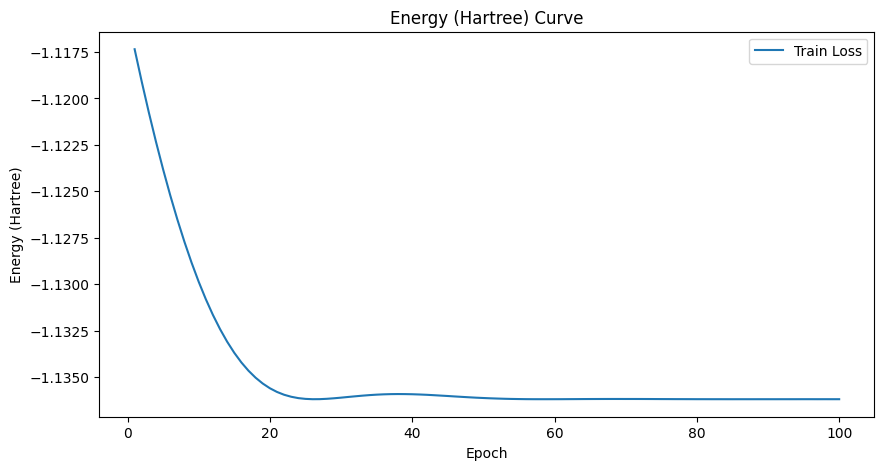

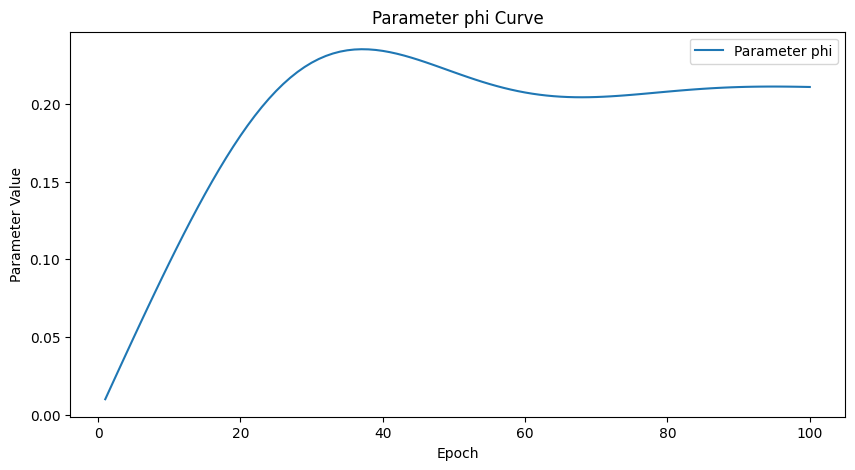

In [6]:
import matplotlib.pyplot as plt

# 绘制 Energy 曲线
plt.figure(figsize=(10, 5))
plt.plot(metrics['epoch'], metrics['train_loss'], label='Train Loss')
plt.title('Energy (Hartree) Curve')
plt.xlabel('Epoch')
plt.ylabel('Energy (Hartree)')
plt.legend()
plt.show()

# 绘制参数变化曲线
param_name = next(iter(metrics['param'][0]))  # 获取第一个参数的名称
param_values = [params[param_name].item() for params in metrics['param']]

plt.figure(figsize=(10, 5))
plt.plot(metrics['epoch'], param_values, label=f'Parameter {param_name}')
plt.title(f'Parameter {param_name} Curve')
plt.xlabel('Epoch')
plt.ylabel('Parameter Value')
plt.legend()
plt.show()

在这个例子中，最优线路参数 $\theta^* = 0.208$ 定义了态：
  
$$\vert \Psi(\theta^*) \rangle = 0.994~\vert 1100 \rangle - 0.104~\vert 0011 \rangle$$

这正是最小基组近似下 $\mathrm{H}_2$ 分子的基态。

结论
----------

在本教程中，我们实现了VQE算法来求解氢分子的基态。我们使用一个简单线路制备超越Hartree-Fock近似的分子量子态。通过最小化试探态下分子哈密顿量期望值定义的损失函数，得到了基态能量。 

参考文献
--------------

[1] Peruzzo A, McClean J, Shadbolt P, et al. A variational eigenvalue solver on a photonic quantum processor[J]. Nature communications, 2014, 5(1): 4213.

[2] Seeley J T, Richard M J, Love P J. The Bravyi-Kitaev transformation for quantum computation of electronic structure[J]. The Journal of chemical physics, 2012, 137(22).